In [1]:
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import numpy as np

from sklearn.model_selection import train_test_split

In [2]:
# Get dataset
df = pd.read_csv('NCVS_HOUSEHOLD_VICTIMIZATION_1993-2019.csv')

In [3]:
df.head()

,year,weight,msa,hincome,hhage,hhgen,hhhisp,hhrace1r,hheth1r,hnumber,popsize,region,notify,newcrime,newoff,vicservices,locationr
0,1993,3219.62735,3,1,3,1,2,1,1,1,NaN,-1,2,3,8,2.0,1
1,1993,3219.62735,3,1,3,1,2,1,1,1,NaN,-1,2,3,8,2.0,1
2,1993,3219.62735,3,1,3,1,2,1,1,1,NaN,-1,2,3,8,2.0,1
3,1993,2999.05015,3,4,2,1,2,1,1,3,NaN,-1,1,3,8,2.0,1
4,1993,2999.05015,3,4,3,2,2,1,1,1,NaN,-1,2,3,8,2.0,1


In [4]:
df.shape

(216269, 17)

In [5]:
df.describe()

,year,weight,msa,hincome,hhage,hhgen,hhhisp,hhrace1r,hheth1r,hnumber,popsize,region,notify,newcrime,newoff,vicservices,locationr
count,216269.000000,216269.000000,216269.000000,216269.000000,216269.000000,216269.000000,216269.000000,216269.000000,216269.000000,216269.000000,177437.000000,216269.000000,216269.000000,216269.0,216269.000000,214994.000000,216269.000000
mean,2004.462822,2539.211250,1.731039,18.443323,3.115338,1.466673,2.208430,1.233825,1.603646,2.206262,1.598133,2.109322,1.661306,3.0,7.584027,1.983279,1.910343
std,8.361142,1954.156798,0.684604,31.214778,0.995070,0.498889,5.383467,0.532468,1.048591,0.819708,1.482455,1.714463,0.537349,0.0,0.781140,0.128226,1.272344
min,1993.000000,33.798650,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,-1.000000,1.000000,3.0,6.000000,1.000000,1.000000
25%,1997.000000,1955.989810,1.000000,3.000000,2.000000,1.000000,2.000000,1.000000,1.000000,2.000000,1.000000,1.000000,1.000000,3.0,8.000000,2.000000,1.000000
50%,2003.000000,2248.094720,2.000000,5.000000,3.000000,1.000000,2.000000,1.000000,1.000000,2.000000,1.000000,3.000000,2.000000,3.0,8.000000,2.000000,1.000000
75%,2012.000000,2812.389420,2.000000,7.000000,4.000000,2.000000,2.000000,1.000000,2.000000,3.000000,2.000000,3.000000,2.000000,3.0,8.000000,2.000000,3.000000
max,2019.000000,79767.074400,3.000000,88.000000,5.000000,2.000000,88.000000,3.000000,4.000000,4.000000,5.000000,4.000000,8.000000,3.0,8.000000,2.000000,5.000000


<b> Observation </b>  
popsize and vicservices have some missing values.

In [6]:
# Find out the number of missing values for popsize and vicservices
df.isnull().sum()

year               0
weight             0
msa                0
hincome            0
hhage              0
hhgen              0
hhhisp             0
hhrace1r           0
hheth1r            0
hnumber            0
popsize        38832
region             0
notify             0
newcrime           0
newoff             0
vicservices     1275
locationr          0
dtype: int64

In [7]:
df.loc[(df['popsize'].isnull()) & (df['vicservices'].isnull())].shape

(165, 17)

<b> Observation </b>  
Out of the 216,269 noted victimisations,  
38832 have empty popsize values (~ 17%) and  
1275 have empty vicservices values (~0.6%)  
And 165 rows have both popsize and vicservices empty (~0.0008%)  

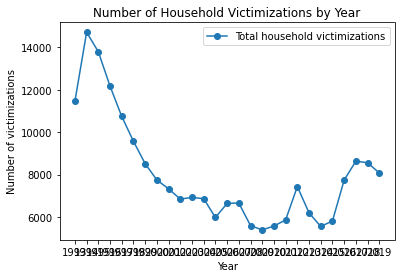

In [8]:
# What is the number of victimizations per year
dfVicPerYear = df.groupby(['year']).size()

figVicPerYear = plt.figure()

axVicPerYear = plt.axes()
axVicPerYear.set_xlabel('Year')
axVicPerYear.set_ylabel('Number of victimizations')
axVicPerYear.set_title('Number of Household Victimizations by Year')

years = []
vicCounts = []
for year, vicCount in dfVicPerYear.groupby(level = 'year'):
  years.append(year)
  vicCounts.append(vicCount)

plt.plot(years, vicCounts, marker='o', label = 'Total household victimizations')
axVicPerYear.legend()

plt.xticks(years)
plt.rcParams["figure.figsize"] = plt.rcParamsDefault["figure.figsize"]
plt.rcParams["figure.figsize"] = (20, 5)

plt.show()


In [9]:
figVicPerYear.savefig('01-number_of_household_victimizations_by_year.pdf', bbox_inches='tight')

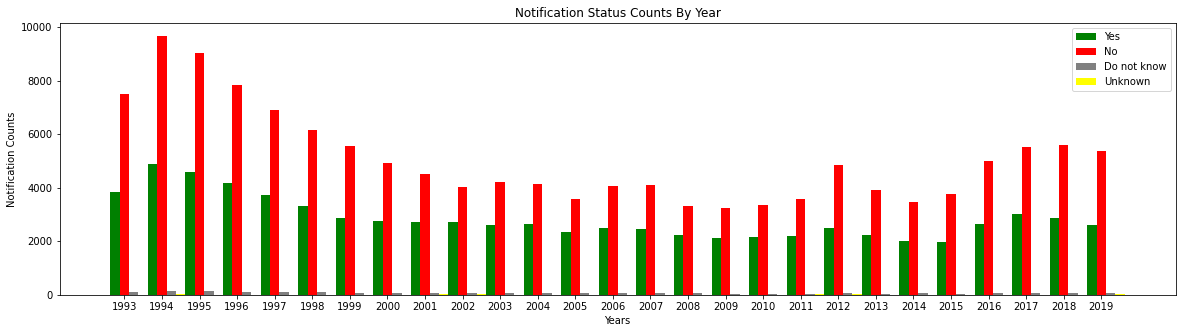

In [10]:
# What are the reporting status (Notified, Not notified, Do not know, Unknown) counts through the Years
dfVicByNotifyPerYear = df.groupby(['year', 'notify']).size()

"""
[
  {
    year: 0,
    1: 0, # Yes
    2: 0, # No
    3: 0, # Do not know
    8: 0, # Unknown
  },
]
"""
notifyStatusPerYear = []

years = []

# Construct notifyStatusPerYear array of dictionaries 
for year, reporting in dfVicByNotifyPerYear.groupby(level = 'year'):
  years.append(year)
  
  notifyInfo = {}
  notifyInfo['year'] = year

  for i in range(len(reporting.keys())):
    notifyStatus = reporting.keys()[i][1]
    notifyStatusVal = reporting.values[i]
    notifyInfo[notifyStatus] = notifyStatusVal
  
  notifyStatusPerYear.append(notifyInfo)

# Function to get notification statuses in an array
def getStatusCounts (notifyStatus):
  notifyStatusCounts = []
  for x in notifyStatusPerYear:
    notifyStatusCounts.append(x[notifyStatus])
  return notifyStatusCounts

# Plot bar graphs
figVicByNotifyPerYear, axVicByNotifyPerYear = plt.subplots()

pltStartingIndex = np.arange(len(years))
width = 0.25

notifyYesCounts = getStatusCounts(1) # 1 = Yes
bar1 = plt.bar(pltStartingIndex, notifyYesCounts, width, color = 'green')

notifyNoCounts = getStatusCounts(2) # 2 = No
bar2 = plt.bar(pltStartingIndex + width, notifyNoCounts, width, color = 'red')

notifyDoNotKnowCounts = getStatusCounts(3) # 3 = Do not know
bar3 = plt.bar(pltStartingIndex + width * 2, notifyDoNotKnowCounts, width, color = 'grey')

notifyUnknownCounts = getStatusCounts(8) # 8 = Unknown
bar4 = plt.bar(pltStartingIndex + width * 3, notifyUnknownCounts, width, color = 'yellow')

plt.xlabel('Years')
plt.ylabel('Notification Counts')
plt.title('Notification Status Counts By Year')

plt.xticks(pltStartingIndex + width, years)
plt.legend( (bar1, bar2, bar3, bar4), ('Yes', 'No', 'Do not know', 'Unknown') )

plt.show()

In [11]:
figVicByNotifyPerYear.savefig('02-notification_status_counts_by_year.pdf', bbox_inches='tight')

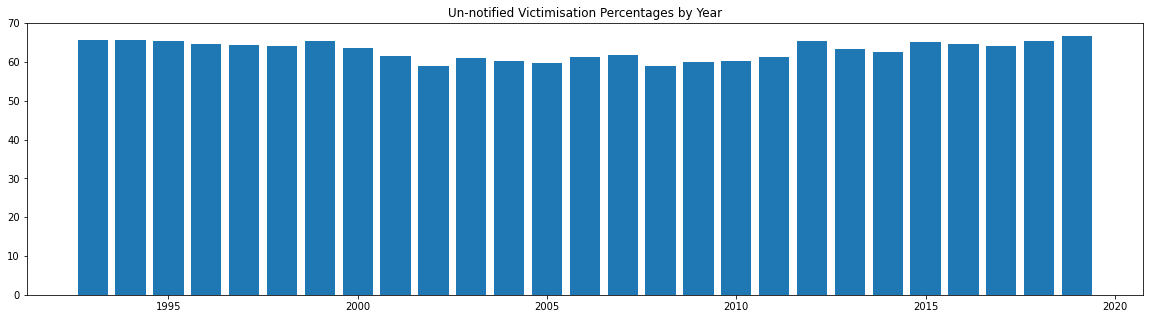

In [12]:
# What is the percentage of the un-notified victimisations through the years
def getPercentageOfUnnotifiedVictimisation (year):
  for x in notifyStatusPerYear:
    if (x['year'] == year):
      return (x[2] / (x[1] + x[2] + x[3] + x[8])) * 100

percentageOfUnnotifiedVictimisationsByYear = []
for year in years:
  percentageOfUnnotifiedVictimisationsByYear.append(getPercentageOfUnnotifiedVictimisation(year))

figUnnotifiedPercentagePerYear = plt.figure()
plt.bar(years, percentageOfUnnotifiedVictimisationsByYear)
plt.title('Un-notified Victimisation Percentages by Year')
plt.show()

In [13]:
figUnnotifiedPercentagePerYear.savefig('03-unnotified-victimisation-percentages-by-year.pdf', bbox_inches='tight')

In [14]:
# Fill in missing popsize values
# With median of popsize values for their corresponding MSAs
dfPreprocessed = df.copy()

dfNotNullPop = df[-df['popsize'].isnull()]

dfNotNullPopMSA1 = dfNotNullPop[dfNotNullPop['msa'] == 1]
medianMSA1 = dfNotNullPopMSA1['popsize'].median()

dfNotNullPopMSA2 = dfNotNullPop[dfNotNullPop['msa'] == 2]
medianMSA2 = dfNotNullPopMSA2['popsize'].median()

dfNotNullPopMSA3 = dfNotNullPop[dfNotNullPop['msa'] == 3]
medianMSA3 = dfNotNullPopMSA3['popsize'].median()

for index, row in df[df['popsize'].isnull()].iterrows():
  if (row['msa'] == 1):
    dfPreprocessed.at[index, 'popsize'] = medianMSA1
  if (row['msa'] == 2):
    dfPreprocessed.at[index, 'popsize'] = medianMSA2
  if (row['msa'] == 3):
    dfPreprocessed.at[index, 'popsize'] = medianMSA3

In [15]:
# Drop rows with empty vicservices
print ('There are ' + str(dfPreprocessed[dfPreprocessed['vicservices'].isnull()].shape[0]) + ' rows with empty vicservices')
print ('Shape of df before dropping empty vicservices rows: ' + str(dfPreprocessed.shape[0]))

dfPreprocessed.dropna(subset=['vicservices'], inplace = True)

print ('Shape of df after dropping empty vicservices rows: ' + str(dfPreprocessed.shape[0]))

There are 1275 rows with empty vicservices
Shape of df before dropping empty vicservices rows: 216269
Shape of df after dropping empty vicservices rows: 214994


In [16]:
# Remove outliers in 'notify' - Part 1
dfPreprocessed.groupby('notify').size()
dfPreprocessed.shape

(214994, 17)

In [17]:
# Remove outliers in 'notify' - Part 2
# There are only 26 columns with notify value '8' (Unknown)

dfPreprocessed = dfPreprocessed[dfPreprocessed['notify'] != 8]
dfPreprocessed.shape

(214968, 17)

In [18]:
dfPreprocessed['notify'].value_counts()

2    136972
1     76119
3      1877
Name: notify, dtype: int64

In [19]:
# Undersample notify 2 rows

sampleToSize = 76119
dfPreprocessed2 = pd.DataFrame()

# Append notify 1
dfPreprocessed2 = dfPreprocessed2.append(dfPreprocessed[dfPreprocessed['notify'] == 1])

# Undersample notify 2
S = dfPreprocessed[dfPreprocessed['notify'] == 2]
dfPreprocessed2 = dfPreprocessed2.append(S.sample(sampleToSize, random_state = 2022))

# Oversample notify 3
S = dfPreprocessed[dfPreprocessed['notify'] == 3]
dfPreprocessed2 = dfPreprocessed2.append(S.sample(sampleToSize, random_state = 2022, replace = True))

dfPreprocessed2.shape

C:\Users\uttej\AppData\Local\Temp\ipykernel_22224\3700006154.py:7: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  dfPreprocessed2 = dfPreprocessed2.append(dfPreprocessed[dfPreprocessed['notify'] == 1])
C:\Users\uttej\AppData\Local\Temp\ipykernel_22224\3700006154.py:11: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  dfPreprocessed2 = dfPreprocessed2.append(S.sample(sampleToSize, random_state = 2022))
C:\Users\uttej\AppData\Local\Temp\ipykernel_22224\3700006154.py:15: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  dfPreprocessed2 = dfPreprocessed2.append(S.sample(sampleToSize, random_state = 2022, replace = True))


(228357, 17)

In [20]:
dfPreprocessed2['notify'].value_counts()

1    76119
2    76119
3    76119
Name: notify, dtype: int64

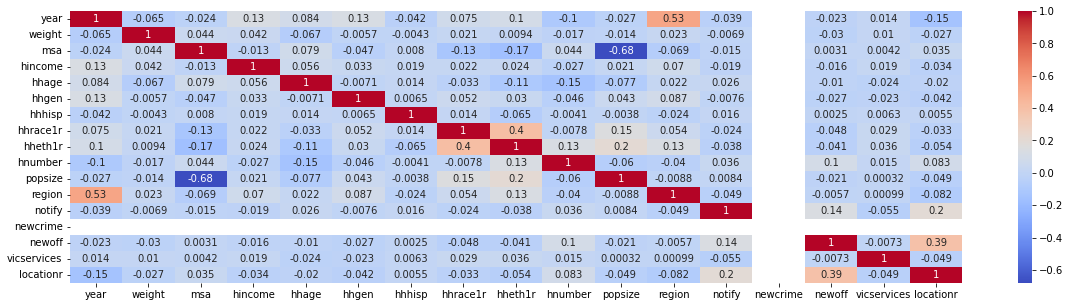

In [21]:
# Find corelations
plt.rcParams["figure.figsize"] = (20, 5)
f = sns.heatmap(dfPreprocessed2.corr(), annot = True, cmap='coolwarm')

In [22]:
# Drop unnecessary columns: weight
dfPreprocessed2.drop('weight', inplace=True, axis=1)

dfPreprocessed2.head()


,year,msa,hincome,hhage,hhgen,hhhisp,hhrace1r,hheth1r,hnumber,popsize,region,notify,newcrime,newoff,vicservices,locationr
3,1993,3,4,2,1,2,1,1,3,1.0,-1,1,3,8,2.0,1
10,1993,1,6,4,1,2,1,1,2,3.0,-1,1,3,8,2.0,1
14,1993,2,88,4,1,2,1,1,2,1.0,-1,1,3,7,2.0,3
22,1993,2,1,2,2,2,1,1,3,1.0,-1,1,3,7,2.0,1
23,1993,2,4,3,1,2,1,1,3,1.0,-1,1,3,8,2.0,3


In [23]:
# One-hot encode all columns except notify, which is the 'Target' column
dfEncoded = pd.get_dummies(data = dfPreprocessed2, columns = [
  'year',
  'msa',
  'hincome',
  'hhage',
  'hhgen',
  'hhhisp',
  'hhrace1r',
  'hheth1r',
  'hnumber',
  'popsize',
  'region',
  'newcrime',
  'newoff',
  'vicservices',
  'locationr'
  ])

dfEncoded.head()


,notify,year_1993,year_1994,year_1995,year_1996,year_1997,year_1998,year_1999,year_2000,year_2001,...,newoff_6,newoff_7,newoff_8,vicservices_1.0,vicservices_2.0,locationr_1,locationr_2,locationr_3,locationr_4,locationr_5
3,1,1,0,0,0,0,0,0,0,0,...,0,0,1,0,1,1,0,0,0,0
10,1,1,0,0,0,0,0,0,0,0,...,0,0,1,0,1,1,0,0,0,0
14,1,1,0,0,0,0,0,0,0,0,...,0,1,0,0,1,0,0,1,0,0
22,1,1,0,0,0,0,0,0,0,0,...,0,1,0,0,1,1,0,0,0,0
23,1,1,0,0,0,0,0,0,0,0,...,0,0,1,0,1,0,0,1,0,0


In [24]:
dfEncoded.groupby(['notify']).size()

notify
1    76119
2    76119
3    76119
dtype: int64

In [25]:
dfPrediction = dfEncoded.copy()

In [26]:
accuracy = dict()

Linear Regression

In [27]:
sample = dfPrediction
Y_sample = sample['notify']
X_sample = sample.drop('notify', axis=1)

X_train, X_validate, y_train, y_validate = train_test_split(X_sample, Y_sample, random_state=2022)

In [28]:
from sklearn.linear_model import LinearRegression
linearModel = LinearRegression(n_jobs = -1)

linearModel.fit(X_train,y_train)

LinearRegression(n_jobs=-1)

In [32]:
from sklearn.metrics import accuracy_score


y_pred = linearModel.predict(X_validate)

accuracy["linear regression"] = accuracy_score(y_validate, y_pred)

ValueError: Classification metrics can't handle a mix of multiclass and continuous targets

In [33]:
accuracy["linear regression"]

KeyError: 'linear regression'

Logistic Regression

In [34]:
sample = dfPrediction
Y_sample = sample['notify']
X_sample = sample.drop('notify', axis=1)

X_train, X_validate, y_train, y_validate = train_test_split(X_sample, Y_sample, random_state=2022)

In [35]:
from sklearn.linear_model import LogisticRegression
logmodel = LogisticRegression(random_state=2022, n_jobs = -1) # use all cores

logmodel.fit(X_train,y_train)

LogisticRegression(n_jobs=-1, random_state=2022)

In [36]:
from sklearn.metrics import accuracy_score
y_pred = logmodel.predict(X_validate)

accuracy["logistic regression"] = accuracy_score(y_validate, y_pred)

In [37]:
accuracy["logistic regression"]

0.4680329304606761

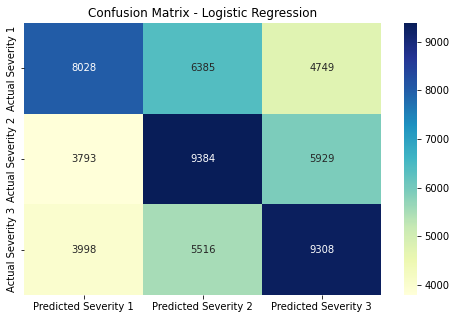

In [43]:
confmat = confusion_matrix(y_true=y_validate, y_pred=y_pred) 

index = ["Actual Severity 1", "Actual Severity 2", "Actual Severity 3"]
columns = ["Predicted Severity 1", "Predicted Severity 2", "Predicted Severity 3"]
conf_matrix = pd.DataFrame(data=confmat, columns=columns, index=index)
plt.figure(figsize=(8, 5))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="YlGnBu")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

In [41]:
print (confmat)

[[8028 6385 4749]
 [3793 9384 5929]
 [3998 5516 9308]]


Support Vector Machine

K-Nearest Neighbours

K-Means

In [27]:
from sklearn.cluster import KMeans

sample = dfPrediction
y_sample = sample['notify']
X_sample = sample.drop('notify', axis=1)

X_train, X_validate, y_train, y_validate = train_test_split(X_sample, y_sample, random_state=2022)
print(X_train.shape, y_train.shape)
print(X_validate.shape, y_validate.shape)

(171267, 81) (171267,)
(57090, 81) (57090,)


In [30]:
y_pred = KMeans(n_clusters=2, random_state=2022).fit(X_train)

In [37]:
print(KMeans.predict(X_validate))


TypeError: KMeans.predict() missing 1 required positional argument: 'X'

Decision Trees

In [176]:
sample = dfPrediction
y_sample = sample['notify']
X_sample = sample.drop('notify', axis=1)

X_train, X_validate, y_train, y_validate = train_test_split(X_sample, y_sample, random_state=2022)
print(X_train.shape, y_train.shape)
print(X_validate.shape, y_validate.shape)

(171267, 81) (171267,)
(57090, 81) (57090,)


In [177]:
from sklearn.tree import DecisionTreeClassifier
dtc = DecisionTreeClassifier(random_state=2022)
dtc.fit(X_train, y_train)

DecisionTreeClassifier(random_state=2022)

In [178]:
print("Train score:", dtc.score(X_train, y_train))
print("Validation score:", dtc.score(X_validate, y_validate))

Train score: 0.9428085971027693
Validation score: 0.7089157470660361


In [179]:
y_pred = dtc.predict(X_validate)

accuracy["Decision tree"]= accuracy_score(y_validate, y_pred)

In [180]:
accuracy["Decision tree"]

0.7089157470660361

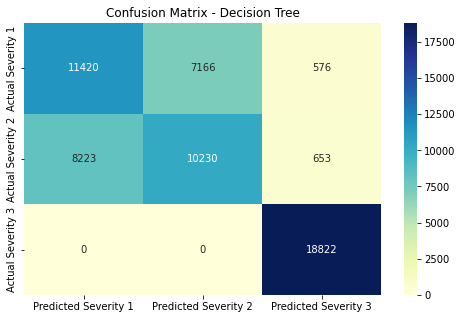

In [181]:
confmat = confusion_matrix(y_true=y_validate, y_pred=y_pred)

index = ["Actual Severity 1", "Actual Severity 2", "Actual Severity 3"]
columns = ["Predicted Severity 1", "Predicted Severity 2", "Predicted Severity 3"]
conf_matrix = pd.DataFrame(data=confmat, columns=columns, index=index)
plt.figure(figsize=(8, 5))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="YlGnBu")
plt.title("Confusion Matrix - Decision Tree")
plt.show()

Random Trees

In [199]:
sample = dfPrediction
y_sample = sample["notify"]
X_sample = sample.drop("notify", axis=1)

X_train, X_validate, y_train, y_validate = train_test_split(X_sample, y_sample, random_state=42)
print(X_train.shape, y_train.shape)
print(X_validate.shape, y_validate.shape)

(171267, 81) (171267,)
(57090, 81) (57090,)


In [200]:
from sklearn.ensemble import RandomForestClassifier
rfc = RandomForestClassifier(n_jobs=-1, random_state=2022)
rfc.fit(X_train, y_train)
print("Train score:", rfc.score(X_train, y_train))
print("Validation score:", rfc.score(X_validate, y_validate))

Train score: 0.9428436301213894
Validation score: 0.7392713259765283


In [201]:
y_pred = rfc.predict(X_validate)

accuracy["Random Forest"] = accuracy_score(y_validate, y_pred)

In [202]:
accuracy["Random Forest"]

0.7392713259765283

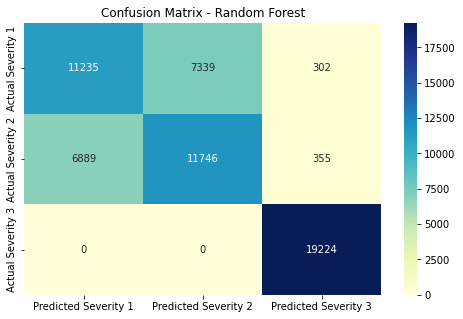

In [203]:
confmat = confusion_matrix(y_true=y_validate, y_pred=y_pred)

index = ["Actual Severity 1", "Actual Severity 2", "Actual Severity 3"]
columns = ["Predicted Severity 1", "Predicted Severity 2", "Predicted Severity 3"]
conf_matrix = pd.DataFrame(data=confmat, columns=columns, index=index)
plt.figure(figsize=(8, 5))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="YlGnBu")
plt.title("Confusion Matrix - Random Forest")
plt.show()

Neural Network

In [204]:
sample = dfPrediction
y_sample = sample["notify"]
X_sample = sample.drop("notify", axis=1)

X_train, X_validate, y_train, y_validate = train_test_split(X_sample, y_sample, random_state=42)
print(X_train.shape, y_train.shape)
print(X_validate.shape, y_validate.shape)

(171267, 81) (171267,)
(57090, 81) (57090,)


In [205]:
from sklearn.neural_network import MLPClassifier
mlp = MLPClassifier(random_state=2022, verbose=False)
mlp.fit(X_train, y_train)

c:\Users\uttej\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:692: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


MLPClassifier(random_state=2022)

In [206]:
print("Train score:", mlp.score(X_train, y_train))
print("Validation score:", mlp.score(X_validate, y_validate))

Train score: 0.7299012652758559
Validation score: 0.7197232440007006


In [ ]:
y_pred = mlp.predict(X_validate)

accuracy["Multi Layer Perceptron"] = accuracy_score(y_validate, y_pred)

In [ ]:
accuracy["Multi Layer Perceptron"]

In [ ]:
confmat = confusion_matrix(y_true=y_validate, y_pred=y_pred)

index = ["Actual Severity 1", "Actual Severity 2", "Actual Severity 3", "Actual Severity 4"]
columns = ["Predicted Severity 1", "Predicted Severity 2", "Predicted Severity 3", "Predicted Severity 4"]
conf_matrix = pd.DataFrame(data=confmat, columns=columns, index=index)
plt.figure(figsize=(8, 5))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="YlGnBu")
plt.title("Confusion Matrix - Multi Layer Perceptron")
plt.show()